# Correct susceptibility distortion from a reversed-polarity pair

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrdistortion/blob/main/examples/04-susceptibility.ipynb)

Two acquisitions of the same anatomy with opposite phase encoding are displaced
in opposite directions along that axis, so the field that displaced them is what
makes one the mirror of the other. PyHySCO recovers it and unwarps both.

Everything here is tensors: the pair goes in as tensors and the field and
corrected images come back as tensors, with nothing written to disk. PyHySCO is
GPL-3.0-only, so it is an optional extra -- ``pip install mrdistortion[epi]``.

In [1]:
try:
    import mrdistortion  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "mrdistortion", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import mrdistortion as mrd

SHAPE = (48, 64, 64)


def displaced_pair(shape=SHAPE, amplitude: float = 4.0):
    """A phantom and the pair a field would displace it into."""
    axes = [torch.linspace(-1, 1, n, dtype=torch.float64) for n in shape]
    rows, columns, planes = torch.meshgrid(*axes, indexing="ij")
    phantom = (
        ((rows / 0.75) ** 2 + (columns / 0.8) ** 2 + (planes / 0.8) ** 2) < 1
    ).double() * (1 + 0.4 * torch.sin(6 * rows) * torch.cos(5 * columns))

    # An air cavity's field: compact, and strongest where the anatomy ends.
    shift = amplitude * torch.exp(-((columns - 0.35) ** 2 + planes**2) / 0.15)
    index = torch.arange(shape[0], dtype=torch.float64)[:, None, None]

    def warp(image, offset):
        source = (index + offset).clamp(0, shape[0] - 1)
        lower = source.floor().long()
        upper = (lower + 1).clamp(max=shape[0] - 1)
        fraction = source - lower
        return (
            image.gather(0, lower.expand_as(image)) * (1 - fraction)
            + image.gather(0, upper.expand_as(image)) * fraction
        )

    return warp(phantom, shift), warp(phantom, -shift), shift

In [3]:
blip_up, blip_down, shift = displaced_pair()
print(
    f"pair {tuple(blip_up.shape)}, imposed displacement up to {shift.max():.1f} voxels"
)

pair (48, 64, 64), imposed displacement up to 4.0 voxels


disagreement between the pair: 0.0500 -> 0.0264 (0.53x)
recovered field spans 4.2 voxels


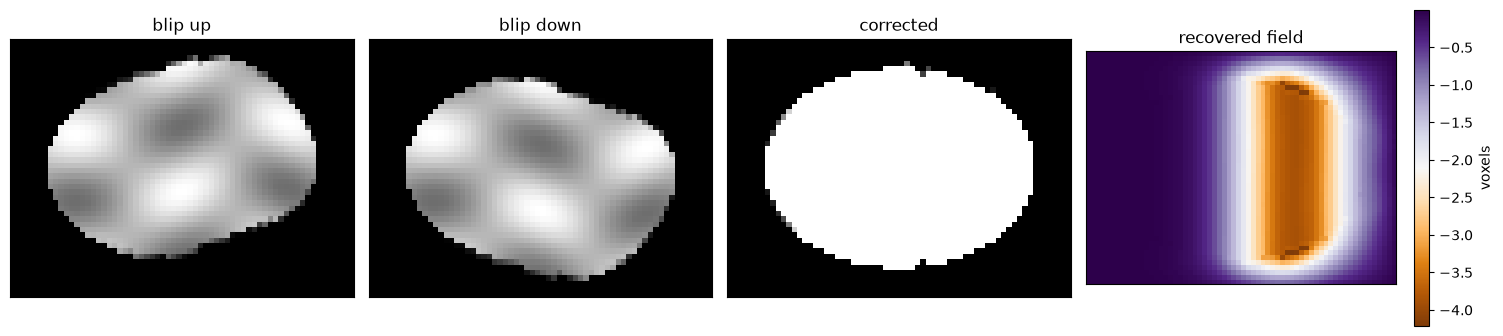

In [4]:
# alpha weights the smoothness of the field and has to suit the scale the
# field varies on. PyHySCO's default of 300 suits a real acquisition, where
# susceptibility varies over centimetres; it flattens a lobe as compact as
# the one simulated here, and the pair ends up agreeing less well than it
# started.
result = mrd.correct_susceptibility(
    blip_up,
    blip_down,
    voxel_size=(1.0, 1.0, 1.0),
    phase_encoding_direction=1,
    alpha=50.0,
    max_iter=30,
)

before = (blip_up - blip_down).abs().mean()
after = (result.blip_up - result.blip_down).abs().mean()
print(
    f"disagreement between the pair: {before:.4f} -> {after:.4f} "
    f"({after / before:.2f}x)"
)
print(f"recovered field spans {result.field_map.abs().max():.1f} voxels")

middle = SHAPE[2] // 2
figure, axes = plt.subplots(1, 4, figsize=(15, 4.2))
top = blip_up.max()
for axis, data, title in (
    (axes[0], blip_up[:, :, middle], "blip up"),
    (axes[1], blip_down[:, :, middle], "blip down"),
    (axes[2], result.blip_up[:, :, middle], "corrected"),
):
    axis.imshow(data.numpy(), cmap="gray", vmin=0, vmax=top)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
shown = axes[3].imshow(result.field_map[:-1, :, middle].numpy(), cmap="PuOr")
axes[3].set_title("recovered field")
axes[3].set_xticks([])
axes[3].set_yticks([])
figure.colorbar(shown, ax=axes[3], fraction=0.046, label="voxels")
figure.tight_layout()
figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "susceptibility.png", dpi=110)